In [202]:
import numpy as np
import pandas as pd
import random
import time
from rapidfuzz import process, fuzz, distance
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import spoa 


# (Generating fresh data to ensure variables exist for the loop below)
n_items = 5000 
pool_bc = [gen_dna(12) for _ in range(n_items)]
pool_ins = [gen_dna(50) for _ in range(n_items)]
# n_repeat_bc = 500
# pool_bc += pool_bc[0:n_repeat_bc]
# pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]
# pool_bc += pool_bc[0:n_repeat_bc]
# pool_ins += [gen_dna(50) for _ in range(n_repeat_bc)]

data = []
for i in range(len(pool_bc)):
     n_reads = random.randint(3, 30) 
     for _ in range(n_reads):
         data.append({
             "ID": i,
             "Barcode": mutate_sequence(pool_bc[i], 0.05), 
             "Insert": mutate_sequence(pool_ins[i], 0.05)
         })

df = pd.DataFrame(data)
if VERBOSE_LEVEL >= 1:
    print(f"Dataset: {len(df)} reads")

barcode_counts = df['Barcode'].value_counts()
all_barcodes = np.array(barcode_counts.index.tolist())

Dataset: 82251 reads


In [98]:
final_clusters

[]


Processing Top Barcode #1: CGACAATCCCTG (Count: 24)
  -> Hamming Driver: Starting at k=1


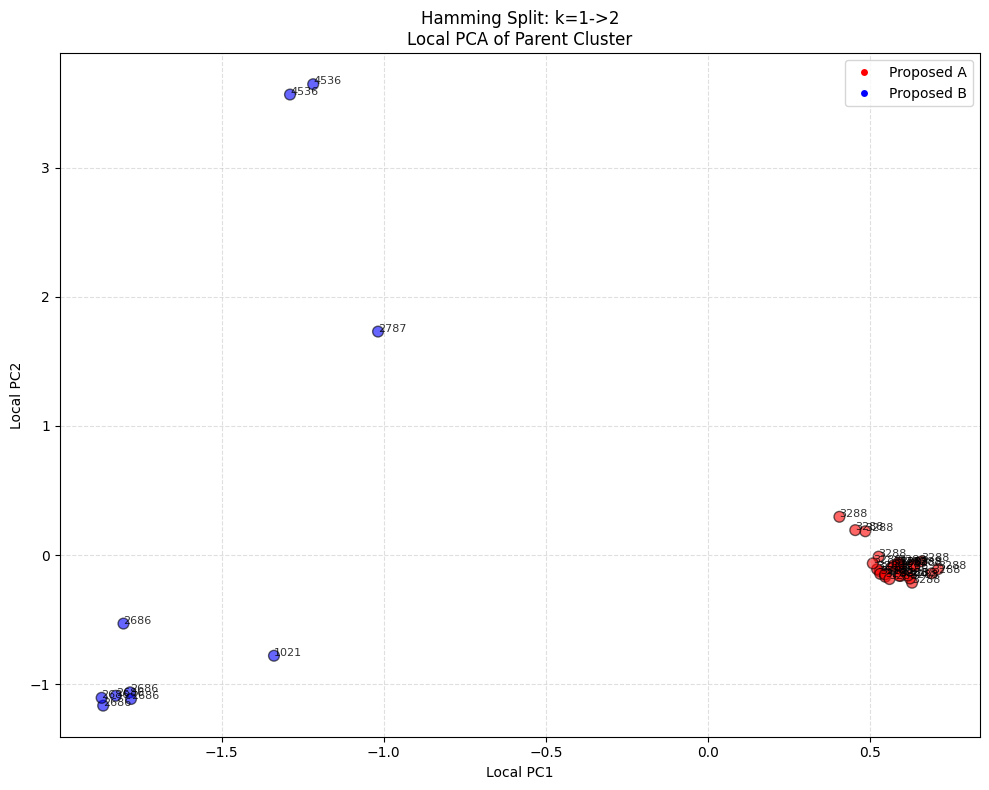

  -> Expansion to k=2 justified.


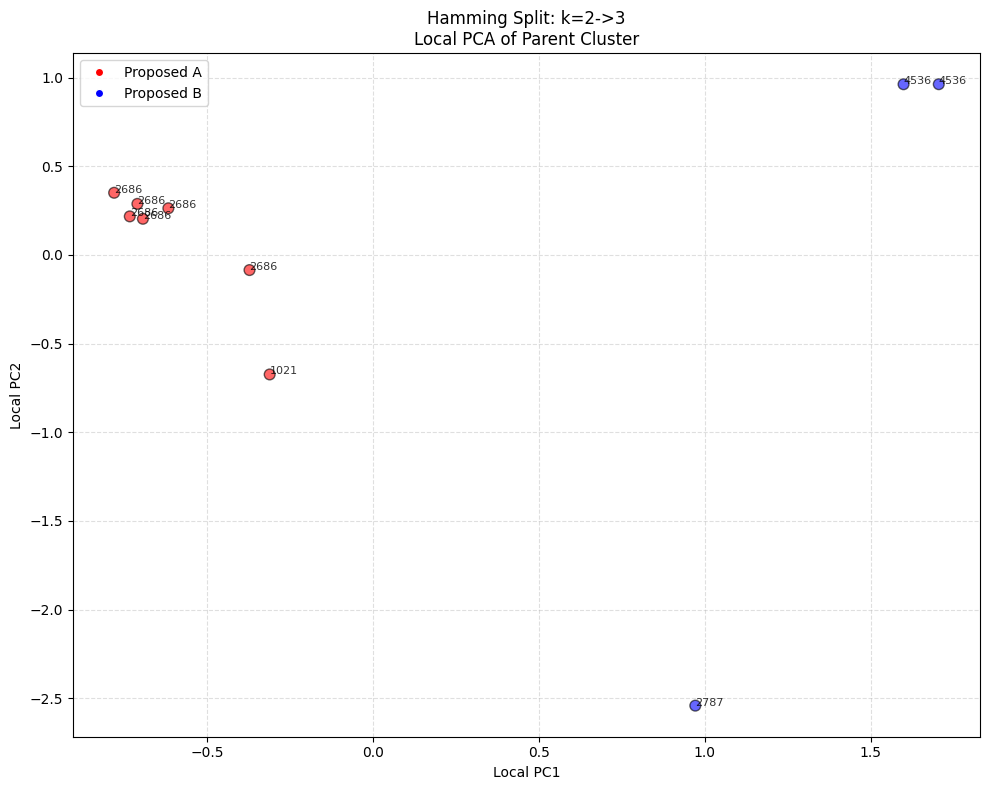

  -> Expansion to k=3 justified.


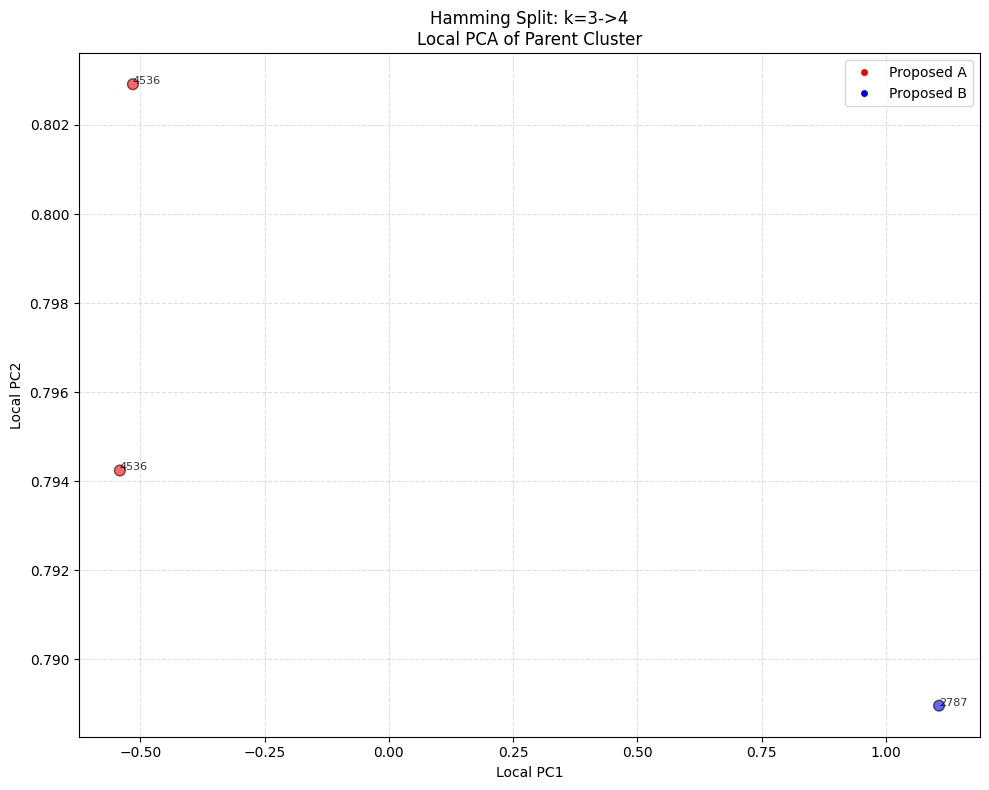

  -> Expansion to k=4 rejected. Stopping.
  > Final Clusters: 3
    Cluster 0: 3 reads
    Cluster 1: 27 reads
    Cluster 2: 7 reads


In [245]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.manifold import spectral_embedding
from rapidfuzz import process, fuzz
import spoa 

# --- 1. CONFIGURATION ---
seed = 42
random.seed(seed)
np.random.seed(seed)
VERBOSE_LEVEL = 1 

# --- 2. DATA GENERATION & UTILS ---
def mutate_sequence(seq, error_rate=0.10):
    if error_rate <= 0: return seq
    seq_list = list(seq)
    new_seq = []
    for base in seq_list:
        if random.random() < error_rate:
            r = random.random()
            if r < 0.5: new_seq.append(random.choice("ACGT")) 
            elif r < 0.75: 
                new_seq.append(base)
                new_seq.append(random.choice("ACGT"))
            else: pass 
        else:
            new_seq.append(base)
    return "".join(new_seq)

def gen_dna(k): return "".join(random.choices("ACGT", k=k))

# Generate Mock Data if running standalone
if 'df' not in locals():
    print("Generating Mock Data...")
    barcodes = [gen_dna(10) for _ in range(5)]
    data = []
    for i, bc in enumerate(barcodes):
        # Create 3 distinct clusters per barcode to test spectral
        inserts = [gen_dna(20) for _ in range(3)]
        for ins_idx, ins in enumerate(inserts):
            for _ in range(30):
                data.append({'Barcode': mutate_sequence(bc, 0.05), 
                             'Insert': mutate_sequence(ins, 0.10), 
                             'ID': f"Grp{i}_C{ins_idx}_{random.randint(0,999)}"}) # Added random ID suffix
    df = pd.DataFrame(data)
    barcode_counts = df['Barcode'].value_counts()
    all_barcodes = df['Barcode'].unique()
    print("Mock Data Generated.\n")

# --- 3. CORE ALGORITHM FUNCTIONS ---

def encode_msa(msa_strings, alphabet="ACGTN-"):
    char_to_int = {c: i for i, c in enumerate(alphabet)}
    max_len = max(len(s) for s in msa_strings)
    msa_padded = [s.ljust(max_len, '-') for s in msa_strings]
    msa_array = np.array([list(seq) for seq in msa_padded])
    N, L = msa_array.shape
    msa_int = np.zeros((N, L), dtype=np.int8)
    for char, idx in char_to_int.items():
        msa_int[msa_array == char] = idx
    return msa_int, len(alphabet)

def get_marginals(msa_int, vocab_size):
    one_hot = np.eye(vocab_size)[msa_int]
    P_i = one_hot.mean(axis=0)
    return one_hot, P_i

def compute_mi_scores(one_hot, P_i):
    N, L, A = one_hot.shape
    flat_view = one_hot.transpose(1, 2, 0).reshape(L * A, N)
    joint_probs_flat = (flat_view @ flat_view.T) / N
    P_ij = joint_probs_flat.reshape(L, A, L, A)
    P_product = P_i[:, :, None, None] * P_i[None, None, :, :]
    mask = P_ij > 0
    mi_matrix = np.zeros_like(P_ij)
    mi_matrix[mask] = P_ij[mask] * np.log(P_ij[mask] / P_product[mask])
    return mi_matrix.sum(axis=(1, 3))

def validate_split_percentile(cluster_A_indices, cluster_B_indices, all_df, local_df,
                              percentile_th=5, n_background_target=1000, verbose=0):
    inserts_A = local_df.loc[cluster_A_indices, 'Insert'].tolist()
    inserts_B = local_df.loc[cluster_B_indices, 'Insert'].tolist()
    
    if not inserts_A or not inserts_B: return False

    subset_A = inserts_A[:100]
    subset_B = inserts_B[:100]
    signal_dist = 100 - process.cdist(subset_A, subset_B, scorer=fuzz.ratio).mean()
    
    remaining_df = all_df.drop(local_df.index, errors='ignore')
    n_background = min(n_background_target, len(remaining_df))
    
    if n_background < 10: 
        return signal_dist > 15.0

    random_inserts = remaining_df.sample(n=n_background)['Insert'].tolist()
    bg_dists_A = 100 - process.cdist(subset_A, random_inserts, scorer=fuzz.ratio)
    bg_dists_B = 100 - process.cdist(subset_B, random_inserts, scorer=fuzz.ratio)
    
    threshold_value = (np.percentile(bg_dists_A, percentile_th) + np.percentile(bg_dists_B, percentile_th))/2
    is_valid = signal_dist > threshold_value 
    
    if verbose >= 2:
        print(f"      [Val] Signal: {signal_dist:.1f} | BG Thresh: {threshold_value:.1f} | Valid: {is_valid}")
        
    return is_valid

def get_elbow_columns(mi_matrix, exclusion_distance=5):
    L = mi_matrix.shape[0]
    mask = np.triu(np.ones((L, L), dtype=bool), k=exclusion_distance + 1)
    rows, cols = np.where(mask)
    scores = mi_matrix[rows, cols]
    
    sorted_indices = np.argsort(scores)[::-1]
    cap = min(100, len(sorted_indices))
    sorted_indices = sorted_indices[:cap]
    sorted_scores = scores[sorted_indices]
    
    if len(sorted_scores) < 3:
        sel_rows = rows[sorted_indices]
        sel_cols = cols[sorted_indices]
        return np.unique(np.concatenate([sel_rows, sel_cols]))

    n_points = len(sorted_scores)
    x_norm = np.linspace(0, 1, n_points)
    y_norm = (sorted_scores - sorted_scores.min()) / (sorted_scores.max() - sorted_scores.min() + 1e-9)
    
    line_vec = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
    line_vec = line_vec / np.linalg.norm(line_vec)
    vec_from_start = np.stack([x_norm - x_norm[0], y_norm - y_norm[0]], axis=1)
    distances = np.abs(vec_from_start[:, 0] * line_vec[1] - vec_from_start[:, 1] * line_vec[0])
    
    elbow_idx = np.argmax(distances)
    n_selected = max(1, elbow_idx)
    selected_indices = sorted_indices[:n_selected]
    return np.unique(np.concatenate([rows[selected_indices], cols[selected_indices]]))

# --- PLOTTING FUNCTIONS ---

def plot_msa_and_pca(msa_int, sub_df_indices, top_cols, vocab_size, title, target_index):
    """Plots final result."""
    msa_subset = msa_int[:, top_cols]
    read_indices = sub_df_indices.tolist()
    N = len(read_indices)
    
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features = subset_one_hot.reshape(N, -1)
    pca = PCA(n_components=min(N, 2), whiten=True)
    coords = pca.fit_transform(features)
    
    fig = plt.figure(figsize=(10, 0.4 * N + 5)) 
    gs = gridspec.GridSpec(2, 2, height_ratios=[max(1, 0.4*N), 4])
    
    ax_msa = fig.add_subplot(gs[0, :])
    cmap_msa = colors.ListedColormap(['#00B050', '#0070C0', '#FFC000', '#FF0000', '#A0A0A0', '#F0F0F0'][:vocab_size])
    ax_msa.imshow(msa_subset, aspect='auto', cmap=cmap_msa, interpolation='nearest', vmin=0, vmax=vocab_size-1)
    ax_msa.set_title(title)
    
    try:
        t_idx = read_indices.index(target_index)
        ax_msa.axhline(y=t_idx - 0.5, color='red', linewidth=2)
        ax_msa.axhline(y=t_idx + 0.5, color='red', linewidth=2)
    except: pass

    ax_pca = fig.add_subplot(gs[1, :])
    if coords.shape[1] >= 2:
        ax_pca.scatter(coords[:, 0], coords[:, 1], alpha=0.7, edgecolors='k')
        ax_pca.set_xlabel("PC1")
        ax_pca.set_ylabel("PC2")
    else:
        ax_pca.scatter(coords[:, 0], np.zeros(N), alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def plot_split_proposal(msa_int, top_cols, vocab_size, parent_indices_int, mask_a, mask_b, ids_list, title):
    """
    Visualizes a specific split proposal by running local PCA on only the parent cluster points.
    ANNOTATES with IDs.
    """
    if len(parent_indices_int) < 3: return

    # 1. Extract features ONLY for the parent cluster
    msa_subset = msa_int[parent_indices_int][:, top_cols]
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features = subset_one_hot.reshape(len(parent_indices_int), -1)
    
    # 2. Run Local PCA (2D)
    pca = PCA(n_components=2, whiten=True)
    coords = pca.fit_transform(features)
    
    # 3. Determine Colors
    color_labels = []
    for idx in parent_indices_int:
        if mask_a[idx]: color_labels.append('red')
        elif mask_b[idx]: color_labels.append('blue')
        else: color_labels.append('lightgray')
    
    # 4. Calculate Jitter ONCE so we can apply it to both dots and text
    jitter_x = np.random.normal(0, 0.05, len(coords))
    jitter_y = np.random.normal(0, 0.05, len(coords))
    
    final_x = coords[:, 0] + jitter_x
    final_y = coords[:, 1] + jitter_y

    # 5. Plot Points
    plt.figure(figsize=(10, 8)) # Made figure larger to accommodate text
    plt.scatter(final_x, final_y, c=color_labels, edgecolor='k', alpha=0.6, s=60)
    
    # 6. Plot Text Labels (IDs)
    # We zip coordinate + ID. ids_list corresponds to parent_indices_int order
    for x, y, uid in zip(final_x, final_y, ids_list):
        plt.text(x, y, str(uid), fontsize=8, alpha=0.8)

    # Create manual legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Proposed A'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Proposed B')
    ]
    plt.legend(handles=legend_elements)
    plt.title(f"{title}\nLocal PCA of Parent Cluster")
    plt.xlabel("Local PC1")
    plt.ylabel("Local PC2")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# --- 4. CLUSTERING ALGORITHM ---

def iterative_hamming_driver(sub_df, all_df, barcode_target, verbose=0):
    
    # A. PREP
    if len(sub_df) < 3: return [sub_df]

    barcodes = sub_df['Barcode'].tolist()
    _, msa_barcodes = spoa.poa(barcodes, algorithm=2) 
    inserts = sub_df['Insert'].tolist()
    _, msa_inserts = spoa.poa(inserts, algorithm=2)
    
    msa_strings = [b + "--------" + i for b, i in zip(msa_barcodes, msa_inserts)]
    msa_int, vocab_size = encode_msa(msa_strings)
    
    _, P_i = get_marginals(msa_int, vocab_size)
    one_hot = np.eye(vocab_size)[msa_int]
    mi_matrix = compute_mi_scores(one_hot, P_i)**2
    
    top_cols = get_elbow_columns(mi_matrix, exclusion_distance=5)
    
    if len(top_cols) == 0:
        return [sub_df]

    # B. DATA SUBSET (THE INPUT FOR CLUSTERING)
    msa_subset = msa_int[:, top_cols]

    # C. PCA (FOR VISUALIZATION ONLY)
    subset_one_hot = np.eye(vocab_size)[msa_subset]
    features_onehot = subset_one_hot.reshape(len(sub_df), -1)
    
    n_samples = len(sub_df)
    n_components = 0.95
    if n_samples < 5: n_components = min(n_samples, 2)
        
    pca = PCA(n_components=n_components, whiten=True)
    coords = pca.fit_transform(features_onehot)

    # D. ITERATIVE EXPANSION
    current_k = 1
    current_labels = np.zeros(len(sub_df), dtype=int)

    clustering_accepted = True
    max_k = min(len(sub_df), 20)
    
    if verbose >= 1:
        print(f"  -> Hamming Driver: Starting at k=1")

    while clustering_accepted and current_k < max_k:
        next_k = current_k + 1
        
        try:
            model_next = AgglomerativeClustering(
                n_clusters=next_k, 
                metric='hamming', 
                linkage='average'
            )
            next_labels = model_next.fit_predict(msa_subset)
        except Exception as e:
            print(f"Clustering failed: {e}")
            break
        
        split_valid = False
        
        # Check every cluster to see if it split
        for old_lbl in np.unique(current_labels):
            indices_old = np.where(current_labels == old_lbl)[0] 
            new_labels_in_group = next_labels[indices_old]
            unique_new = np.unique(new_labels_in_group)
            
            if len(unique_new) > 1:
                counts = pd.Series(new_labels_in_group).value_counts()
                if len(counts) < 2: continue
                
                lbl_a = counts.index[0]
                lbl_b = counts.index[1]
                
                mask_a = (next_labels == lbl_a) & (current_labels == old_lbl)
                mask_b = (next_labels == lbl_b) & (current_labels == old_lbl)
                
                idx_A = sub_df.index[mask_a]
                idx_B = sub_df.index[mask_b]
                
                if verbose >= 2:
                    print(f"    Checking split of Cluster {old_lbl} -> New sizes {len(idx_A)} vs {len(idx_B)}")

                # --- VISUALIZE SPLIT ---
                # EXTRACT IDS HERE
                ids_for_plot = sub_df.iloc[indices_old]['ID'].tolist()
                
                plot_split_proposal(msa_int, top_cols, vocab_size, 
                                    indices_old, mask_a, mask_b, 
                                    ids_list=ids_for_plot, # PASS IDs
                                    title=f"Hamming Split: k={current_k}->{next_k}")
                
                # --- VALIDATE ---
                if validate_split_percentile(idx_A, idx_B, all_df, sub_df, verbose=verbose):
                    split_valid = True
                    break 
        
        if split_valid:
            if verbose >= 1: print(f"  -> Expansion to k={next_k} justified.")
            current_k = next_k
            current_labels = next_labels
        else:
            if verbose >= 1: print(f"  -> Expansion to k={next_k} rejected. Stopping.")
            clustering_accepted = False

    # E. RETURN
    TARGET_INDEX_TO_PLOT = 70342 
    if TARGET_INDEX_TO_PLOT in sub_df.index:
         plot_msa_and_pca(
            msa_int, sub_df.index, top_cols, vocab_size,
            title=f"Hamming Final: k={current_k}", target_index=TARGET_INDEX_TO_PLOT
        )
        
    final_clusters = []
    for lbl in np.unique(current_labels):
        final_clusters.append(sub_df.iloc[np.where(current_labels == lbl)[0]])
        
    return final_clusters

# --- 5. EXECUTION LOOP ---

if 'barcode_counts' not in locals():
    barcode_counts = df['Barcode'].value_counts()
    all_barcodes = df['Barcode'].unique()

for i, (top_bc, count) in enumerate(barcode_counts.head(1).items()):
    print("\n" + "="*50)
    print(f"Processing Top Barcode #{i+1}: {top_bc} (Count: {count})")

    top_bc = "TGGCTTCCCCAG" # Force specific barcode if needed for debug
    
    # RapidFuzz
    scores = process.cdist([top_bc], all_barcodes, scorer=fuzz.ratio, dtype=np.uint8)[0]
    candidate_bcs = all_barcodes[np.where(scores > 85)[0]]
    filtered_df = df[df['Barcode'].isin(candidate_bcs)].copy()

    if filtered_df.empty: continue
    
    if VERBOSE_LEVEL >= 2:
        print(f"  > RapidFuzz gathered {len(filtered_df)} reads")

    result_dfs = iterative_hamming_driver(filtered_df, df, top_bc, verbose=VERBOSE_LEVEL)
    
    print(f"  > Final Clusters: {len(result_dfs)}")
    for j, c in enumerate(result_dfs):
        print(f"    Cluster {j}: {len(c)} reads")

In [242]:
result_dfs

[         ID        Barcode                                             Insert
 45681  2787  TGCGCGTTCCCCG  ATAATGTACCCCTTAACCTGAAGAAGGATGCCTCGGCGACGGGGAT...
 74907  4536    TCGGCTCCCAG  ATTTAGAGCTCCCCACCTTCAAGAACTCACGGGAGCAGAAGATGAT...
 74919  4536  TCAGGCTCCCCAG  ATTTAGAGCTGCCCACCTTCAAGAACTCAGGGAGCAGAAGATGTAT...,
          ID        Barcode                                             Insert
 54113  3288    TGGCTCCCCAG  ACTCGCCATGGGCTCAATTAGGATCATTGCGCCGAGTTACTTTTAT...
 54114  3288   TGGCTTCCCCAG  ACTCGCCATGGGCTCAATTAGGTCATCGCCCGAGTTACTTTTATAG...
 54116  3288   TGGCTTCCCCAG  ACTCGCCATTGGGCTCAATAAGTCAATGCCCGAGTTACTTTTATAA...
 54117  3288   TGGCTTCCCCAG  ACTCGCCATGGGCTCAATTAGGTCATTGCCCGAGTTACTTTATAGTCCC
 54118  3288   TGGCTTCCCCAG  ACTCGCCATGGGCCAATTAGGTCATTGCCCGTGTTACTTTTACTAG...
 54119  3288   TGGCTTACCCAG  ACTCGCCATGGGCTCAATTAGGTCATTGCCCGAGTTACTTTTATAG...
 54120  3288   TGGCTTCCCCAG  ACTCGCCATGGGCTCAAGAAGGTCACTGCCCGAGTTACTTTTATAG...
 54121  3288   TGGCTTTCCCAG  ACTCGCCTGGGCTCAATTAGGT

In [228]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

# Your matrix
X = np.array([
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 0, 1, 1, 0, 1, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 1, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [3, 1, 1, 1, 0, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 1, 2, 5], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [5, 1, 1, 1, 0, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 5, 1, 1, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [0, 1, 1, 5, 0, 0, 5, 1, 3], # Noisy
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [1, 1, 1, 1, 0, 0, 5, 1, 3],
 [3, 3, 5, 0, 3, 1, 2, 2, 5], # <-- TARGET CLUSTER
 [3, 3, 5, 0, 3, 1, 2, 2, 5], # <-- TARGET CLUSTER
 [3, 3, 5, 0, 3, 1, 2, 2, 5]  # <-- TARGET CLUSTER
])

# Use Agglomerative Clustering with Hamming Distance
# distance_threshold=0.3 means "Separate clusters if their sequences differ by more than 30%"
model = AgglomerativeClustering(
    n_clusters=None, 
    distance_threshold=0.2,  
    metric='hamming', 
    linkage='average'
)

labels = model.fit_predict(X)

print(f"Clusters Found: {len(np.unique(labels))}")
print("-" * 30)
for lbl in np.unique(labels):
    indices = np.where(labels == lbl)[0]
    print(f"Cluster {lbl}: {len(indices)} items (Indices: {indices})")

Clusters Found: 6
------------------------------
Cluster 0: 26 items (Indices: [ 0  1  2  3  4  5  6  7  9 10 11 12 14 15 16 17 18 19 20 22 23 24 25 26
 28 29])
Cluster 1: 3 items (Indices: [30 31 32])
Cluster 2: 1 items (Indices: [27])
Cluster 3: 1 items (Indices: [21])
Cluster 4: 1 items (Indices: [8])
Cluster 5: 1 items (Indices: [13])
